In [1]:
import numpy as np
from scipy.optimize import minimize, differential_evolution
import matplotlib.pyplot as plt

In [2]:
def objective(x, y):
    """
    Full objective J(x, y).

    x: outer-layer design variable
    y: inner-layer actuation/control variable
    """
    return (x - 2.0)**2 + (y - np.sin(3.0*x))**2 + 0.1*y**2

In [3]:
def inner_optimization(x_fixed):
    """
    Inner layer:
    Given x, find the best y.
    """

    def inner_objective(y_array):
        y = y_array[0]
        return objective(x_fixed, y)

    # Initial guess for y
    y0 = np.array([0.0])

    # Bounds for y
    y_bounds = [(-3.0, 3.0)]

    result = minimize(
        inner_objective,
        y0,
        method="L-BFGS-B",
        bounds=y_bounds
    )

    y_star = result.x[0]
    J_star = result.fun

    return y_star, J_star

In [4]:
x_test = 1.0
y_star, J_star = inner_optimization(x_test)

print("For x =", x_test)
print("Best y =", y_star)
print("Best objective =", J_star)

For x = 1.0
Best y = 0.1282909170588971
Best objective = 1.0018104415158924


In [5]:
def outer_objective(x_array):
    """
    Outer-layer objective.

    The outer optimizer chooses x.
    For each x, we solve the inner optimization over y.
    """
    x = x_array[0]

    y_star, J_star = inner_optimization(x)

    return J_star

In [6]:
# Bounds for x
x_bounds = [(-2.0, 4.0)]

outer_result = differential_evolution(
    outer_objective,
    bounds=x_bounds,
    tol=1e-8,
    polish=True,
    seed=1
)

x_star = outer_result.x[0]
y_star, J_star = inner_optimization(x_star)

print("Optimal x:", x_star)
print("Optimal y:", y_star)
print("Minimum objective:", J_star)

Optimal x: 2.0420934543952103
Optimal y: -0.1420562926950548
Minimum objective: 0.003991657912334112


In [7]:
def one_layer_objective(z):
    """
    One-layer optimization over both x and y.
    """
    x = z[0]
    y = z[1]
    return objective(x, y)

bounds = [
    (-2.0, 4.0),  # x bounds
    (-3.0, 3.0)   # y bounds
]

one_layer_result = differential_evolution(
    one_layer_objective,
    bounds=bounds,
    tol=1e-8,
    polish=True,
    seed=1
)

x_one = one_layer_result.x[0]
y_one = one_layer_result.x[1]
J_one = one_layer_result.fun

print("One-layer optimal x:", x_one)
print("One-layer optimal y:", y_one)
print("One-layer minimum objective:", J_one)

One-layer optimal x: 2.0420928573746213
One-layer optimal y: -0.1420577335018426
One-layer minimum objective: 0.003991657912896377


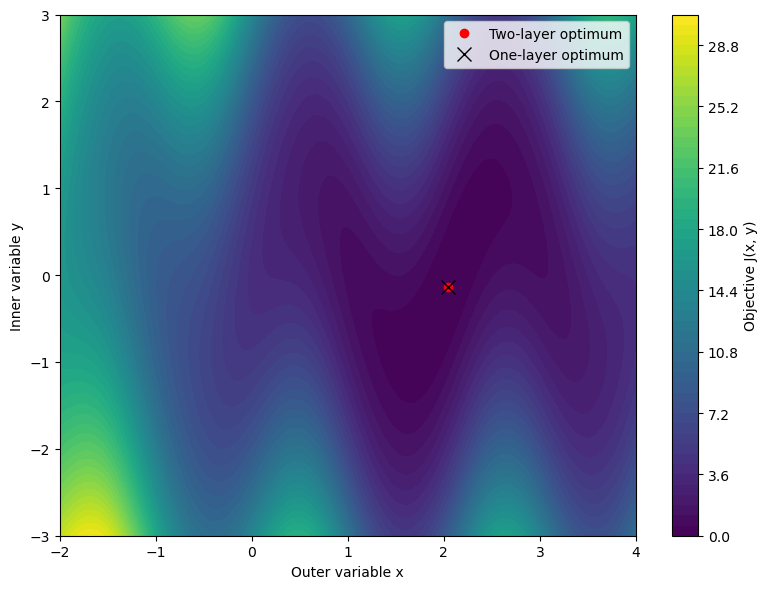

In [8]:
x_vals = np.linspace(-2, 4, 300)
y_vals = np.linspace(-3, 3, 300)

X, Y = np.meshgrid(x_vals, y_vals)
Z = objective(X, Y)

plt.figure(figsize=(8, 6))
contour = plt.contourf(X, Y, Z, levels=50)
plt.colorbar(contour, label="Objective J(x, y)")

plt.plot(x_star, y_star, "ro", label="Two-layer optimum")
plt.plot(x_one, y_one, "kx", markersize=10, label="One-layer optimum")

plt.xlabel("Outer variable x")
plt.ylabel("Inner variable y")
plt.legend()
plt.tight_layout()
plt.show()

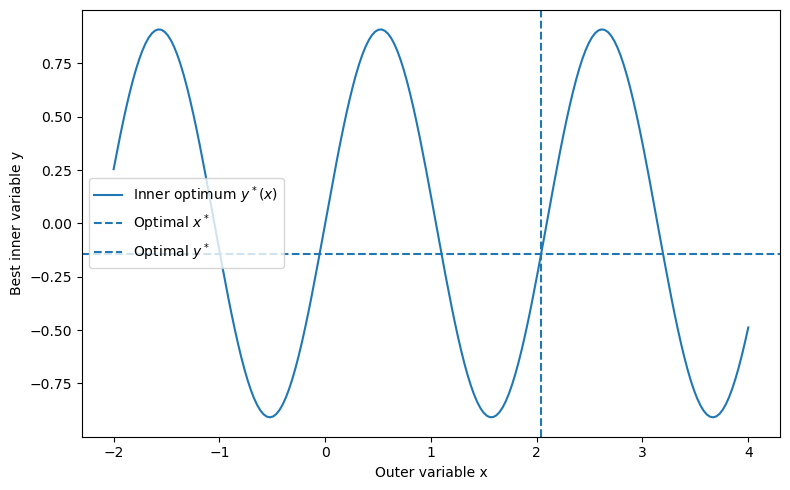

In [9]:
x_scan = np.linspace(-2, 4, 200)

y_star_list = []
J_star_list = []

for x in x_scan:
    y_opt, J_opt = inner_optimization(x)
    y_star_list.append(y_opt)
    J_star_list.append(J_opt)

y_star_list = np.array(y_star_list)
J_star_list = np.array(J_star_list)

plt.figure(figsize=(8, 5))
plt.plot(x_scan, y_star_list, label=r"Inner optimum $y^*(x)$")
plt.axvline(x_star, linestyle="--", label=r"Optimal $x^*$")
plt.axhline(y_star, linestyle="--", label=r"Optimal $y^*$")
plt.xlabel("Outer variable x")
plt.ylabel("Best inner variable y")
plt.legend()
plt.tight_layout()
plt.show()

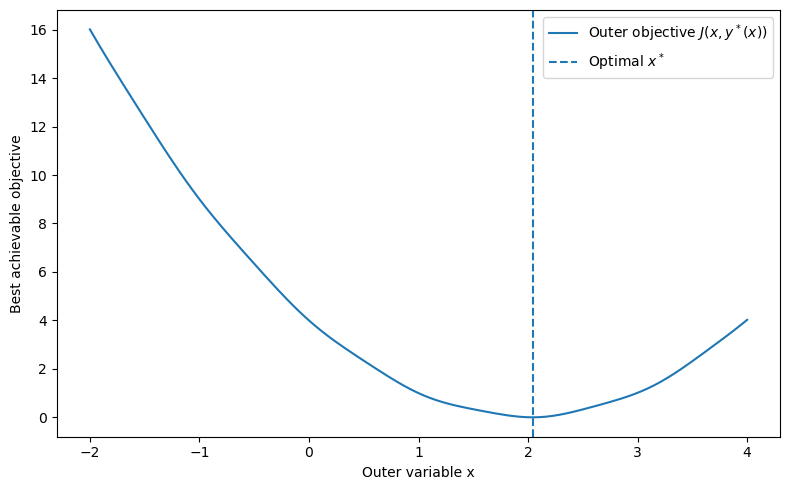

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(x_scan, J_star_list, label=r"Outer objective $J(x,y^*(x))$")
plt.axvline(x_star, linestyle="--", label=r"Optimal $x^*$")
plt.xlabel("Outer variable x")
plt.ylabel("Best achievable objective")
plt.legend()
plt.tight_layout()
plt.show()